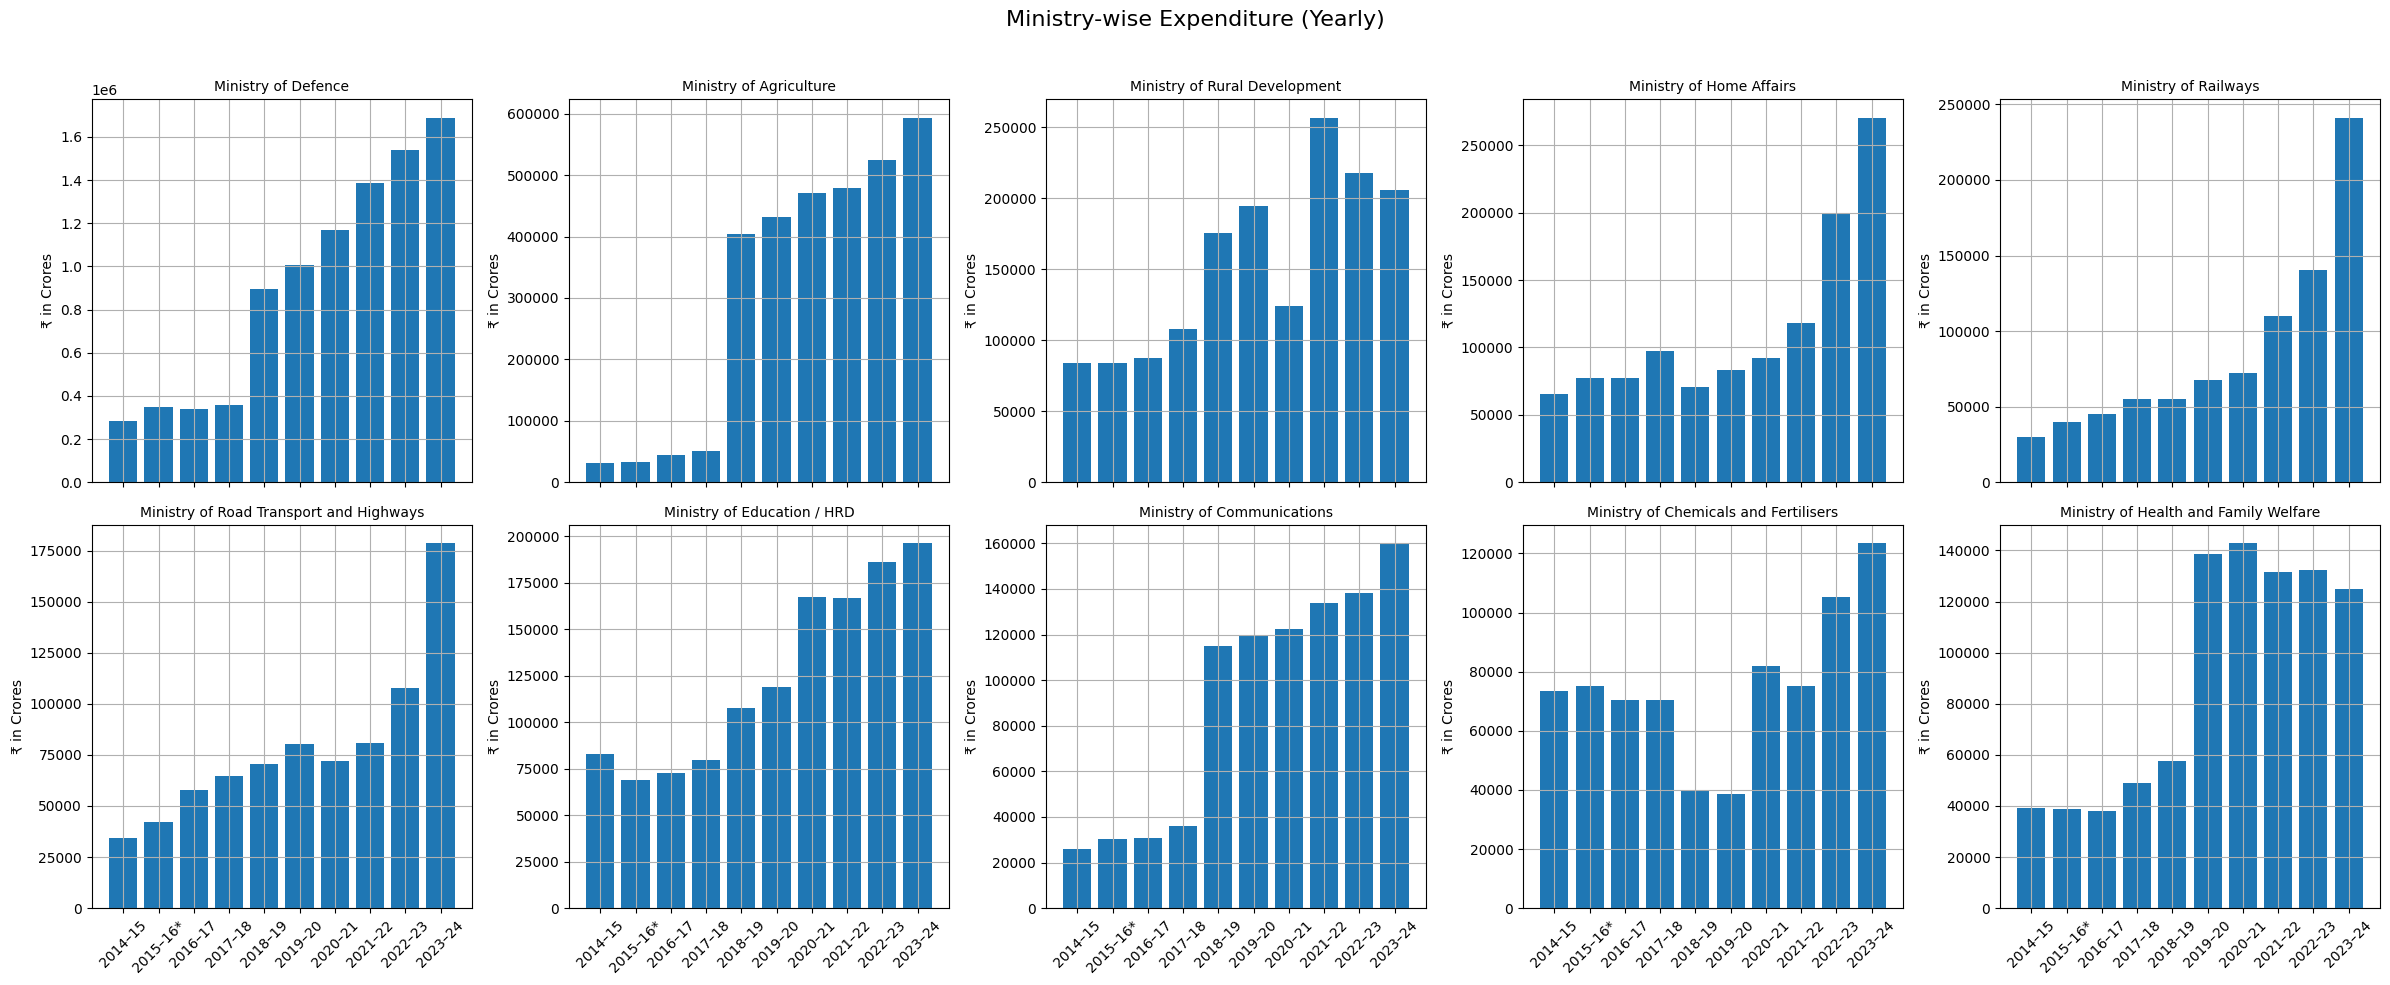

In [14]:
from pyspark.sql import SparkSession
import pandas as pd
import matplotlib.pyplot as plt

# Step 1: Read CSV with PySpark
spark = SparkSession.builder.getOrCreate()
df_spark = spark.read.csv("Data.csv", header=True, inferSchema=True)

# Step 2: Convert to Pandas
df_pd = df_spark.toPandas()

# Step 3: Clean column names
df_pd.columns = df_pd.columns.str.strip()

# Step 4: Set index and transpose
df_pd.set_index('Ministry', inplace=True)
df_transposed = df_pd.T  # Years become index

# Step 5: Plot each ministry in its own subplot (5x2 grid)
ministries = df_transposed.columns.tolist()
years = df_transposed.index.tolist()

fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(24, 10), sharex=True)
axes = axes.flatten()  # flatten 2D array to 1D

for i, ministry in enumerate(ministries):
    ax = axes[i]
    ax.bar(years, df_transposed[ministry])
    ax.set_title(ministry, fontsize=10)
    ax.tick_params(axis='x', rotation=45)
    ax.set_ylabel('₹ in Crores')
    ax.grid(True)

fig.suptitle("Ministry-wise Expenditure (Yearly)", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])  # leave space for suptitle
plt.show()


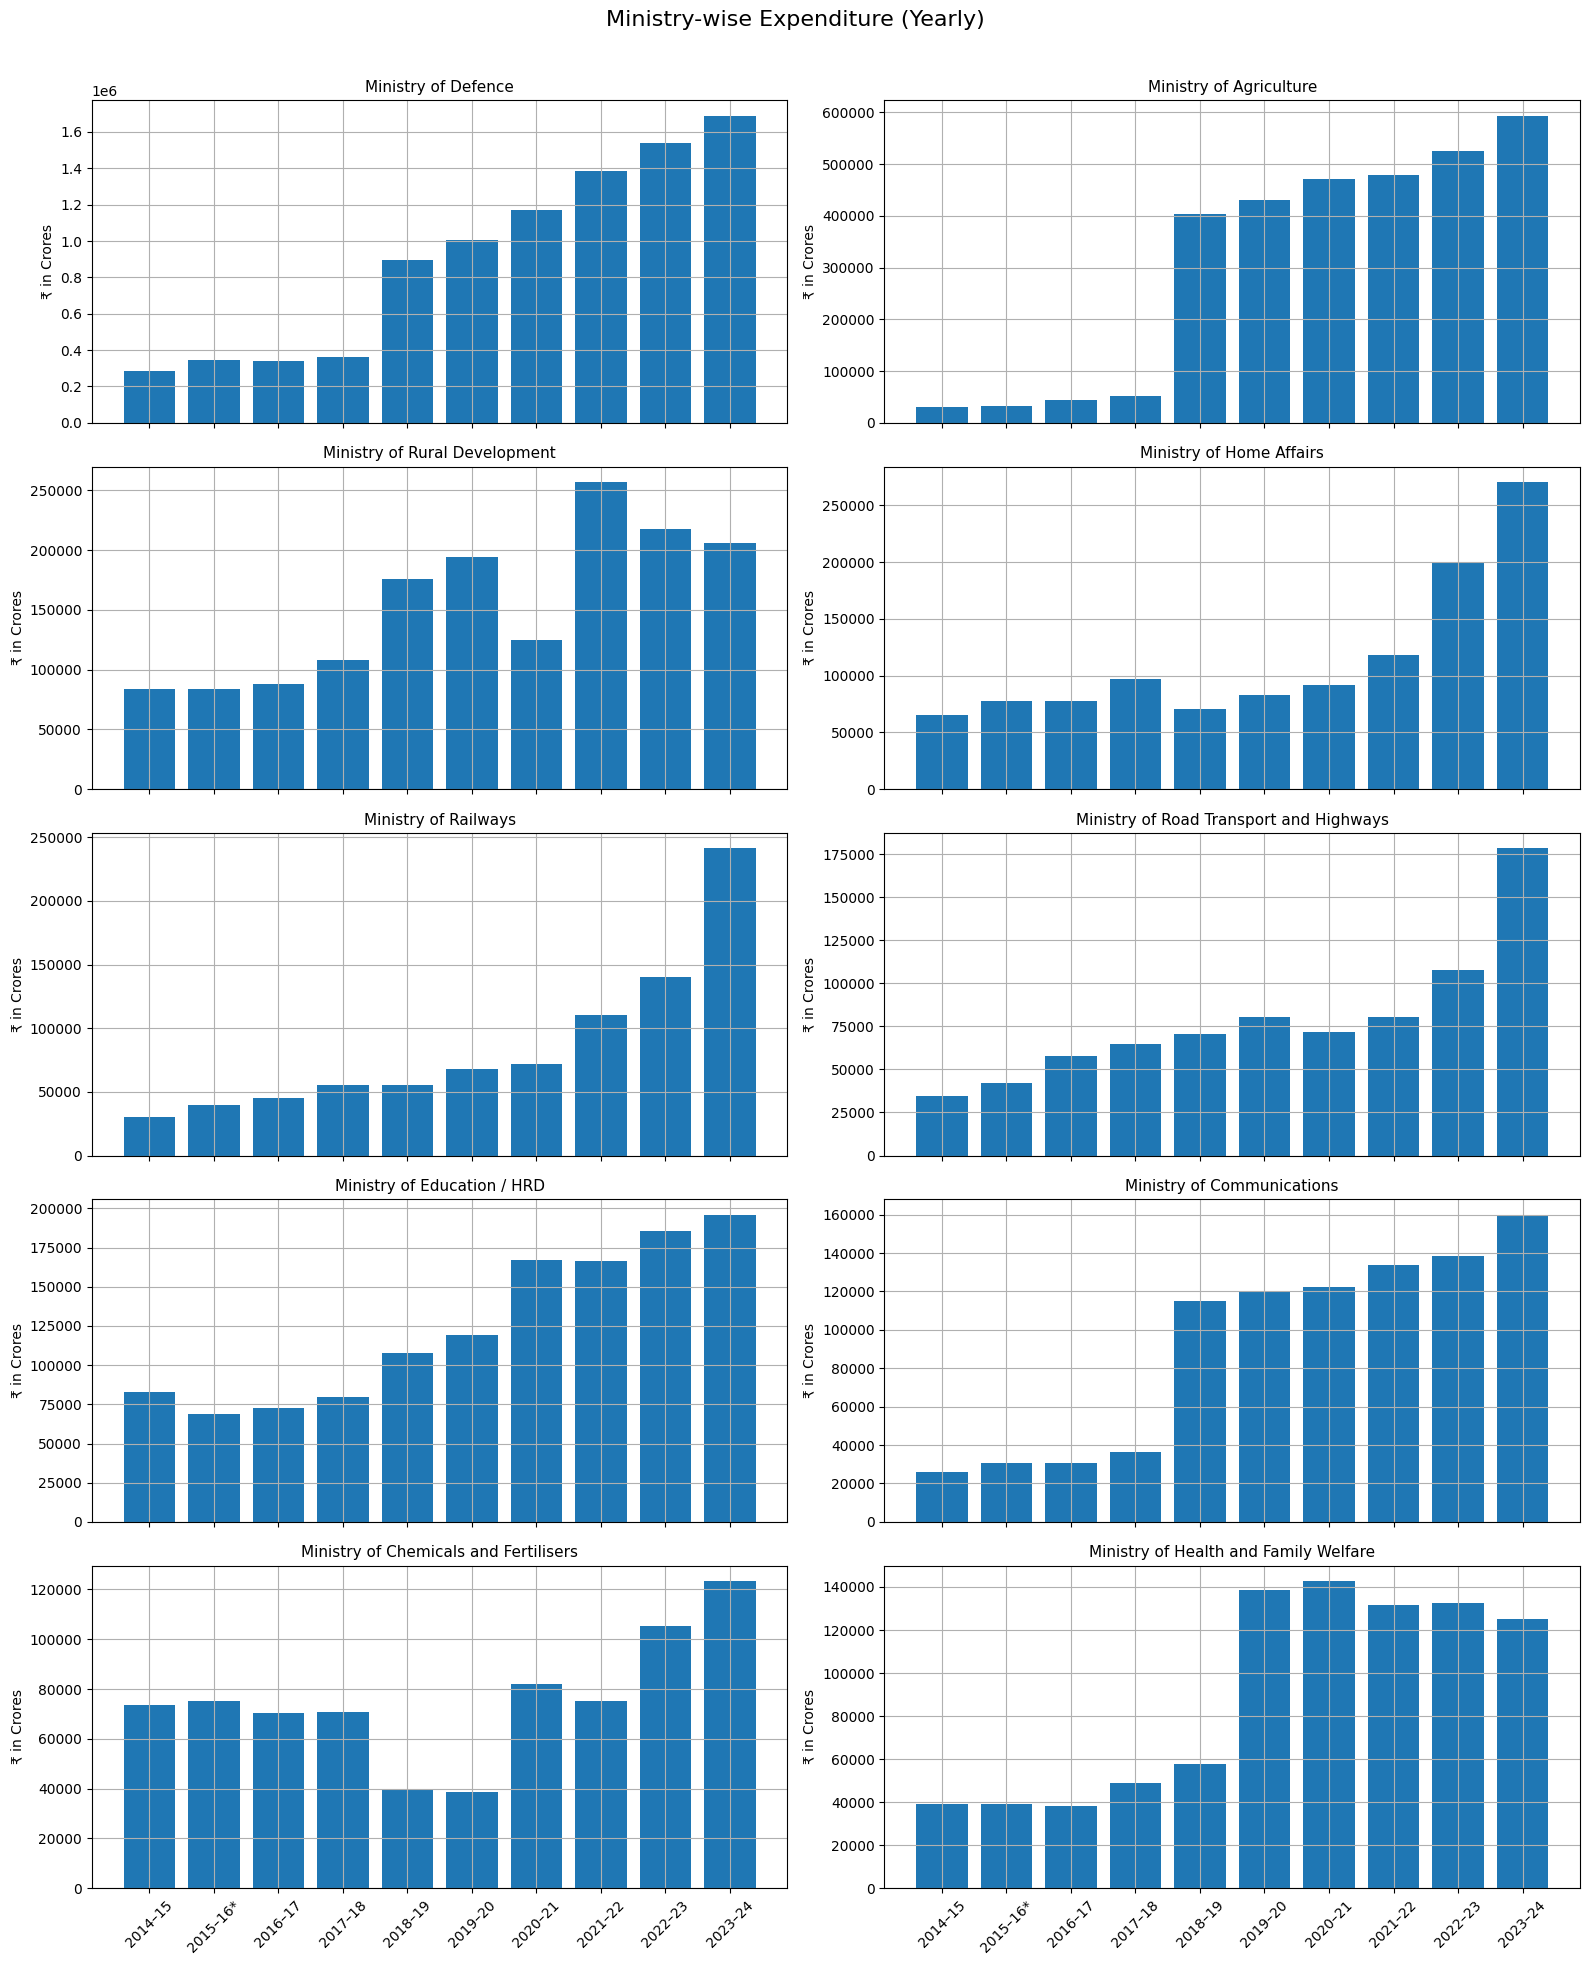

In [15]:
from pyspark.sql import SparkSession
import pandas as pd
import matplotlib.pyplot as plt

# Step 1: Read CSV with PySpark
spark = SparkSession.builder.getOrCreate()
df_spark = spark.read.csv("Data.csv", header=True, inferSchema=True)

# Step 2: Convert to Pandas
df_pd = df_spark.toPandas()

# Step 3: Clean column names
df_pd.columns = df_pd.columns.str.strip()

# Step 4: Set index and transpose
df_pd.set_index('Ministry', inplace=True)
df_transposed = df_pd.T  # Years as rows

# Step 5: Plot in 5 rows × 2 columns
ministries = df_transposed.columns.tolist()
years = df_transposed.index.tolist()

fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(16, 20), sharex=True)
axes = axes.flatten()  # Flatten to 1D array for easy looping

for i, ministry in enumerate(ministries):
    ax = axes[i]
    ax.bar(years, df_transposed[ministry])
    ax.set_title(ministry, fontsize=11)
    ax.tick_params(axis='x', rotation=45)
    ax.set_ylabel("₹ in Crores")
    ax.grid(True)

# Turn off any extra empty subplots (in case fewer ministries)
for j in range(len(ministries), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Ministry-wise Expenditure (Yearly)", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


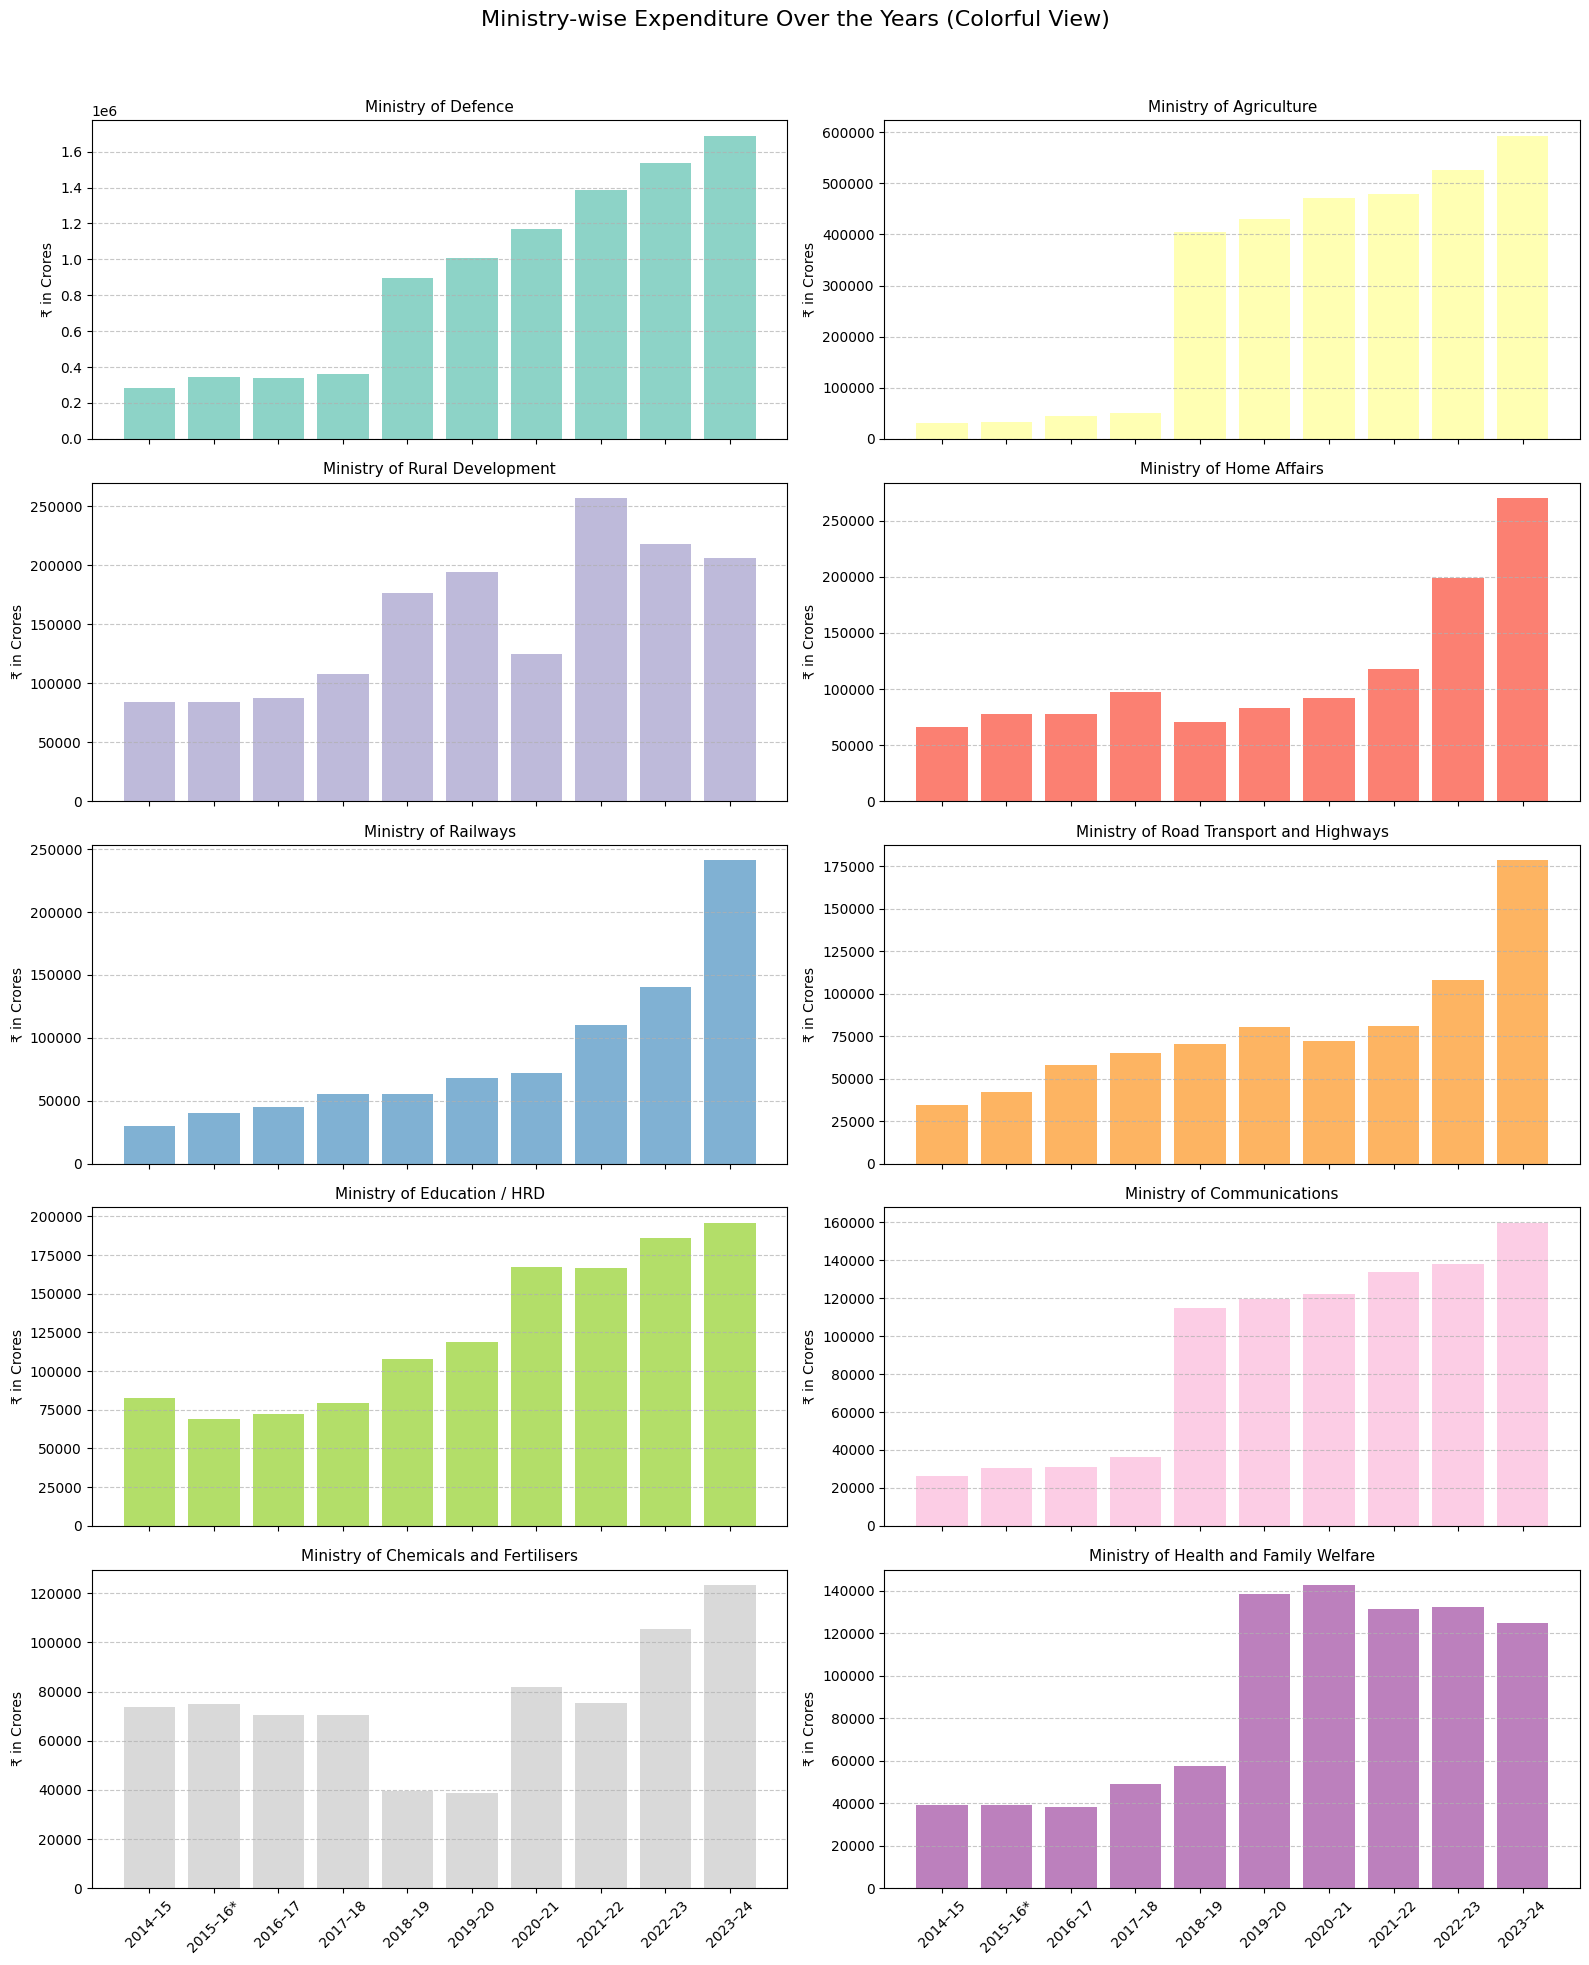

In [16]:
from pyspark.sql import SparkSession
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns  # For a nice color palette

# Step 1: Read CSV with PySpark
spark = SparkSession.builder.getOrCreate()
df_spark = spark.read.csv("Data.csv", header=True, inferSchema=True)

# Step 2: Convert to Pandas
df_pd = df_spark.toPandas()

# Step 3: Clean column names
df_pd.columns = df_pd.columns.str.strip()

# Step 4: Set index and transpose
df_pd.set_index('Ministry', inplace=True)
df_transposed = df_pd.T  # Years as rows

# Step 5: Set up plotting
ministries = df_transposed.columns.tolist()
years = df_transposed.index.tolist()

# Use a colorful palette with 10 distinct colors
palette = sns.color_palette("Set3", n_colors=len(ministries))

# Create 5x2 subplot grid
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(16, 20), sharex=True)
axes = axes.flatten()

for i, ministry in enumerate(ministries):
    ax = axes[i]
    ax.bar(years, df_transposed[ministry], color=palette[i])
    ax.set_title(ministry, fontsize=11)
    ax.tick_params(axis='x', rotation=45)
    ax.set_ylabel("₹ in Crores")
    ax.grid(axis='y', linestyle='--', alpha=0.7)

# Remove any unused subplot
for j in range(len(ministries), len(axes)):
    fig.delaxes(axes[j])

# Title and layout
fig.suptitle("Ministry-wise Expenditure Over the Years (Colorful View)", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()
